# EDA — Corredores Complementarios

- **Dataset crudo:** `data_processed/raw/corredores_hora.parquet`
- **Origen:** hoja `CORREDORES COMPLEMENTARIOS`
- **Periodo:** 2025 · **Grano:** ruta × paradero × sentido × fecha × hora


| Bloque | Columnas |
|--------|----------|
| Demanda | `validaciones` |
| Ruta / paradero | `ruta`, `cod_paradero`, `paradero`, `sentido` |
| Temporal archivo | `fecha`, `hora`, `tipo_dia_archivo` |


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RAIZ = Path.cwd().resolve().parents[1]
RAW = RAIZ / "data_processed" / "raw"
CLEAN = RAIZ / "data_processed" / "clean"
FIGS = RAIZ / "docs" / "images"
CLEAN.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

ANIO = 2025
UMBRAL_COBERTURA = 90
DIAS = ["LUN", "MAR", "MIÉ", "JUE", "VIE", "SÁB", "DOM"]
ORDEN_DIAS = DIAS

FERIADOS_PERU = {
    "2025-01-01": "Anio Nuevo", "2025-04-17": "Jueves Santo", "2025-04-18": "Viernes Santo",
    "2025-05-01": "Dia del Trabajo", "2025-06-29": "San Pedro y San Pablo",
    "2025-07-29": "Fiestas Patrias", "2025-08-30": "Santa Rosa de Lima",
    "2025-10-08": "Combate de Angamos", "2025-11-01": "Todos los Santos",
    "2025-12-08": "Inmaculada Concepcion", "2025-12-25": "Navidad",
}

MAPA_SENTIDO = {
    "NS": ("NS", "N->S"), "SN": ("NS", "S->N"),
    "NORTE-SUR": ("NS", "N->S"), "SUR-NORTE": ("NS", "S->N"),
    "OE": ("EO", "E->O"), "EO": ("EO", "O->E"),
    "OESTE-ESTE": ("EO", "E->O"), "ESTE-OESTE": ("EO", "O->E"),
    "IDA": ("NS", "N->S"), "VUELTA": ("NS", "S->N"),
    "N->S": ("NS", "N->S"), "S->N": ("NS", "S->N"),
    "E->O": ("EO", "E->O"), "O->E": ("EO", "O->E"),
    "N-S": ("NS", "N->S"), "S-N": ("NS", "S->N"),
}

COLOR = "#4f81bd"
SISTEMA = "corredor"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": True,
})
sns.set_style("whitegrid")


def guardar_fig(nombre: str) -> None:
    destino = FIGS / nombre
    plt.savefig(destino, bbox_inches="tight")
    plt.show()  # inline en la celda + archivo en docs/images
    plt.close()
    print(f"  [figura] {destino.relative_to(RAIZ)}")


def anadir_calendario(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.to_datetime(df["fecha"], errors="coerce")
    out = df.copy()
    out["fecha"] = f.dt.normalize()
    out["anio"] = f.dt.year.astype("Int16")
    out["mes"] = f.dt.month.astype("Int8")
    dow = f.dt.dayofweek
    out["dia_semana"] = [DIAS[int(i)] if pd.notna(i) else None for i in dow]
    out["tipo_dia"] = np.select(
        [dow.isna(), dow <= 4, dow == 5, dow == 6],
        [None, "LAB", "SAB", "DOM"], default=None,
    )
    out["semana_iso"] = f.dt.isocalendar().week.astype("Int16")
    clave = out["fecha"].dt.strftime("%Y-%m-%d")
    out["feriado"] = clave.map(FERIADOS_PERU)
    out["es_feriado"] = out["feriado"].notna()
    return out


def ids_texto(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = (out[c].astype("string").str.replace(r"\.0$", "", regex=True).str.strip())
    return out


def normalizar_sentido(df: pd.DataFrame, col: str = "sentido") -> pd.DataFrame:
    out = df.copy()
    bruto = out[col].astype("string").str.strip().str.upper()
    par = bruto.map(MAPA_SENTIDO)
    out["sentido_norm"] = par.map(lambda t: t[1] if isinstance(t, tuple) else None)
    out["eje"] = par.map(lambda t: t[0] if isinstance(t, tuple) else None)
    out["sentido_crudo"] = bruto
    return out


def marcar_franja(hora: pd.Series) -> pd.Series:
    return pd.cut(
        hora.astype(int),
        bins=[-1, 5, 9, 15, 20, 24],
        labels=["madrugada", "pico_am", "valle", "pico_pm", "noche"],
    )


def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - k * iqr), float(q3 + k * iqr), float(q1), float(q3), float(iqr)


print(f"Sistema: {SISTEMA}")
print(f"RAW  : {RAW}")
print(f"CLEAN: {CLEAN}")


Sistema: corredor
RAW  : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/raw
CLEAN: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/clean


## 1. Carga del dataset crudo


In [2]:
ruta = RAW / "corredores_hora.parquet"
if not ruta.exists():
    raise FileNotFoundError(f"Falta {ruta}. Ejecuta prepare_parquet.py --anio {ANIO}")
df = pd.read_parquet(ruta)
print(f"Filas: {len(df):,} | Columnas: {list(df.columns)}")
df.head()


Filas: 8,254,152 | Columnas: ['fecha', 'tipo_dia_archivo', 'ruta', 'cod_paradero', 'paradero', 'sentido', 'hora', 'validaciones']


,fecha,tipo_dia_archivo,ruta,cod_paradero,paradero,sentido,hora,validaciones
0,2025-01-01,MIÉ,201,2ARENAEO,ARENALES,EO,0,NaN
1,2025-01-01,MIÉ,201,2ARENAEO,ARENALES,EO,1,NaN
2,2025-01-01,MIÉ,201,2ARENAEO,ARENALES,EO,2,NaN
3,2025-01-01,MIÉ,201,2ARENAEO,ARENALES,EO,3,NaN
4,2025-01-01,MIÉ,201,2ARENAEO,ARENALES,EO,4,NaN


## 2. Inspección inicial


In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (100 * df.isna().mean()).round(2),
    "unicos": df.nunique(dropna=False),
})
print(info.to_string())
df[["validaciones"]].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T


                           dtype    nulos  nulos_%  unicos
fecha             datetime64[us]        0     0.00     365
tipo_dia_archivo             str        0     0.00       7
ruta                       int64        0     0.00      26
cod_paradero                 str        0     0.00     907
paradero                     str        0     0.00     417
sentido                      str        0     0.00       7
hora                       int64        0     0.00      24
validaciones             float64  3721623    45.09    1152


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
validaciones,4532529.0,19.506664,38.459477,1.0,1.0,1.0,3.0,8.0,21.0,73.0,173.0,1519.0


## 3. Limpieza

### 3.1 Calendario, IDs, sentidos y `tipo_dia_coincide`

El Excel trae `TIPO DE DÍA`; lo contrastamos con el día calendario real.


In [ ]:
df = anadir_calendario(df)
df = ids_texto(df, ["ruta", "cod_paradero", "paradero"])
df["hora"] = pd.to_numeric(df["hora"], errors="coerce").astype("Int16")
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce")
antes = len(df)
df["era_celda_vacia"] = df["validaciones"].isna()
n_na = int(df["era_celda_vacia"].sum())
n_zero_escritos = int((df["validaciones"] == 0).sum())
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce").fillna(0)
df = df[df["validaciones"] >= 0].copy()  # conserva ceros; NA->0+flag
print(f"NA→0+flag: {n_na:,} | ceros escritos: {n_zero_escritos:,} | filas panel={len(df):,}")
df = normalizar_sentido(df)
df["tipo_dia_coincide"] = (
    df["tipo_dia_archivo"].astype("string").str.upper()
    == df["dia_semana"].str.replace("á", "A").str.upper()
)
print(f"despues limpieza (panel con ceros): {len(df):,} ({100*len(df)/antes:.2f}% de {antes:,})")
print(f"tipo_dia_coincide: {df['tipo_dia_coincide'].mean():.4%}")
print(f"sin sentido_norm: {df['sentido_norm'].isna().sum()}")
print(df.groupby(["sentido_crudo","sentido_norm","eje"], dropna=False).size().reset_index(name="n").to_string(index=False))


NA→0+flag: 3,721,623 | ceros escritos: 0 | filas panel=8,254,152
despues limpieza (panel con ceros): 8,254,152 (100.00% de 8,254,152)
tipo_dia_coincide: 100.0000%
sin sentido_norm: 48
sentido_crudo sentido_norm eje       n
        257 A          NaN NaN      48
           EO         O->E  EO 1570632
          IDA         N->S  NS    5904
           NS         N->S  NS 2626800
           OE         E->O  EO 1574640
           SN         S->N  NS 2464824
       VUELTA         S->N  NS   11304


### 3.2 Cobertura por ruta


ruta  dias_con_datos  dias_esperados  pct_cobertura  fiable
3100               1             365            0.3   False
 257               2             365            0.5   False
 304               3             365            0.8   False
 358               5             365            1.4   False
 409               7             365            1.9   False
 306              36             365            9.9   False
 401              58             365           15.9   False
 357             121             365           33.2   False
3090             126             365           34.5   False
2011             174             365           47.7   False
 302             229             365           62.7   False
3180             246             365           67.4   False
 336             303             365           83.0   False
 303             319             365           87.4   False
 301             365             365          100.0    True
 206             365             365    

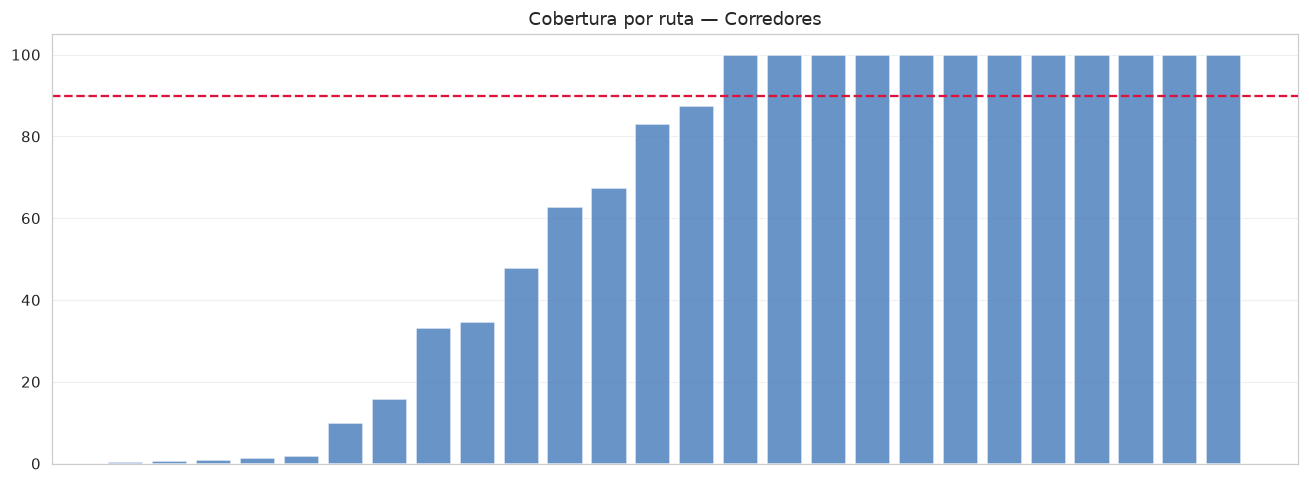

  [figura] docs/images/eda_corredores_cobertura.png
Filas fiables + sentido OK: 7,112,472


In [5]:
dias_esperados = pd.date_range(f"{ANIO}-01-01", f"{ANIO}-12-31").normalize().nunique()
cob = (df.groupby("ruta")["fecha"].nunique().rename("dias_con_datos").reset_index())
cob["dias_esperados"] = dias_esperados
cob["pct_cobertura"] = (100 * cob["dias_con_datos"] / dias_esperados).round(1)
cob["fiable"] = cob["pct_cobertura"] >= UMBRAL_COBERTURA
print(cob.sort_values("pct_cobertura").to_string(index=False))
print(f"Fiables: {cob['fiable'].sum()}/{len(cob)}")
fig, ax = plt.subplots(figsize=(12, 4.5))
orden = cob.sort_values("pct_cobertura")
ax.bar(range(len(orden)), orden["pct_cobertura"], color=COLOR, alpha=0.85)
ax.axhline(UMBRAL_COBERTURA, color="crimson", ls="--")
ax.set_xticks([]); ax.set_title("Cobertura por ruta — Corredores")
guardar_fig("eda_corredores_cobertura.png")
rutas_fiables = set(cob.loc[cob["fiable"], "ruta"].astype(str))
df_f = df[df["ruta"].astype(str).isin(rutas_fiables) & df["sentido_norm"].notna()].copy()
print(f"Filas fiables + sentido OK: {len(df_f):,}")


## 4. Feature engineering


In [6]:
df["franja"] = marcar_franja(df["hora"])
df["log_val"] = np.log1p(df["validaciones"])
diario = (df.groupby(["ruta","fecha"], as_index=False)["validaciones"].sum()
          .rename(columns={"validaciones":"val_dia"}))
lo, hi, q1, q3, iqr = iqr_bounds(diario["val_dia"])
diario["es_outlier_iqr"] = (diario["val_dia"] < lo) | (diario["val_dia"] > hi)
df = df.merge(diario[["ruta","fecha","es_outlier_iqr"]], on=["ruta","fecha"], how="left")
print(f"IQR ruta-día [{lo:,.0f},{hi:,.0f}] outliers={diario['es_outlier_iqr'].mean():.2%}")


IQR ruta-día [-25,782,50,592] outliers=4.26%


## 5. Outliers (IQR)

**Decisión: No eliminarlos del dataset limpio.** En demanda de transporte los
valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR] suelen ser **picos reales**
(días de hub, eventos, punta acumulada). Borrar outliers sesgaría justo la cola
que un modelo de aforo/espera necesita aprender.

Sí los **marcamos** (`es_outlier_iqr`) para inspeccionarlos, estratificar el
análisis y, si hace falta, usar `log1p` en modelado.


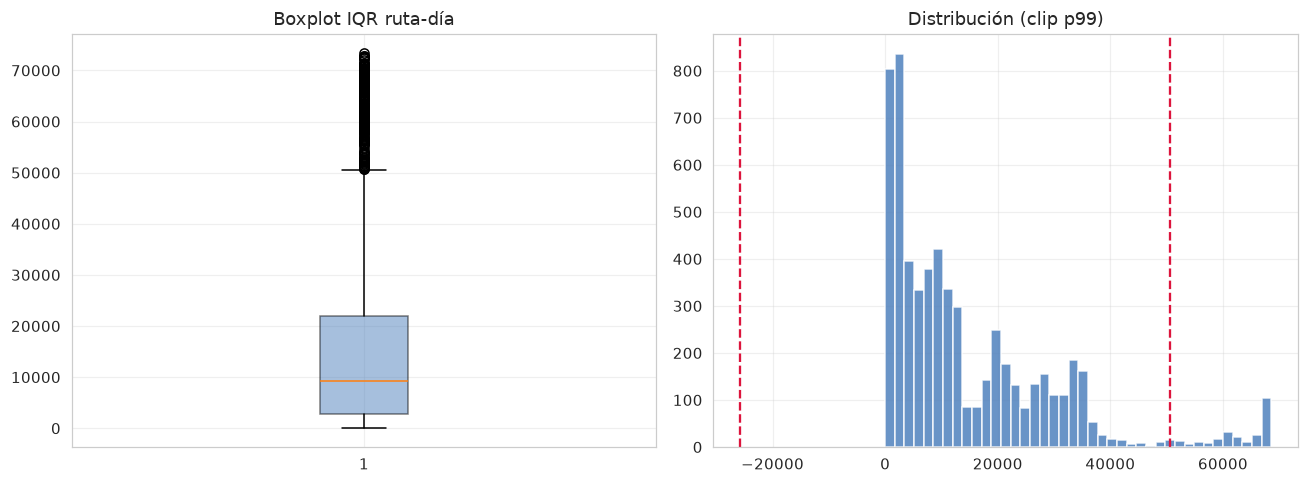

  [figura] docs/images/eda_corredores_outliers_iqr.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].boxplot(diario["val_dia"], showfliers=True, patch_artist=True,
                boxprops=dict(facecolor=COLOR, alpha=0.5))
axes[0].set_title("Boxplot IQR ruta-día")
axes[1].hist(diario["val_dia"].clip(upper=diario["val_dia"].quantile(0.99)), bins=40, color=COLOR, alpha=0.85)
axes[1].axvline(lo, color="crimson", ls="--"); axes[1].axvline(hi, color="crimson", ls="--")
axes[1].set_title("Distribución (clip p99)")
guardar_fig("eda_corredores_outliers_iqr.png")


## 6. Análisis

### 6.1 Univariado


Total: 88,414,521 | rutas=26


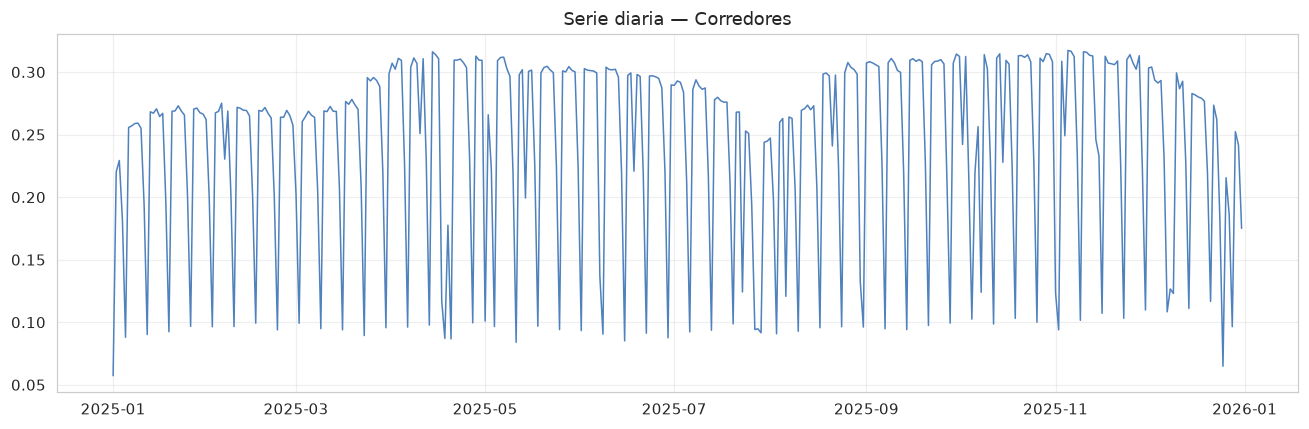

  [figura] docs/images/eda_corredores_serie_diaria.png


In [8]:
print(f"Total: {df['validaciones'].sum():,.0f} | rutas={df['ruta'].nunique()}")
serie = df.groupby("fecha")["validaciones"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie.index, serie.values/1e6, color=COLOR, lw=1)
ax.set_title("Serie diaria — Corredores")
guardar_fig("eda_corredores_serie_diaria.png")


### 6.2 Horario, ranking y sentidos (bivariado)


hora
7     24.0
17    21.0
6     21.0
18    20.0
8     19.0
06-10h 33.1% | 16-20h 31.9%


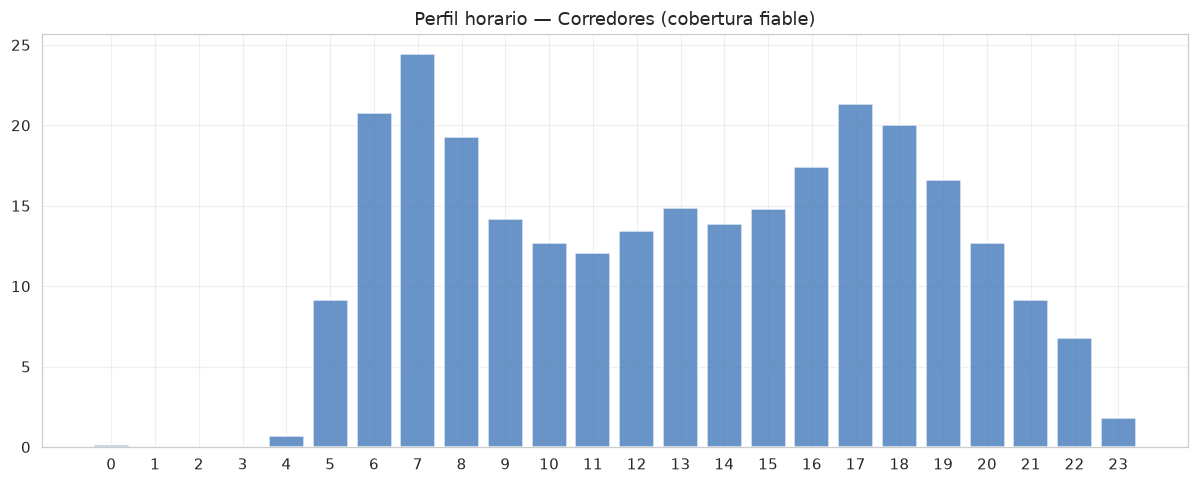

  [figura] docs/images/eda_corredores_perfil_horario.png
      validaciones  dias  share_%
ruta                             
201     20122713.0   365     25.0
301     10263995.0   365     12.0
204     10180006.0   365     12.0
206      9460663.0   365     12.0
209      7865355.0   365     10.0
404      6880657.0   365      8.0
412      5957316.0   365      7.0
305      3985210.0   365      5.0
405      3648147.0   365      4.0
406      1752261.0   365      2.0
370      1059804.0   365      1.0
371       630616.0   365      1.0


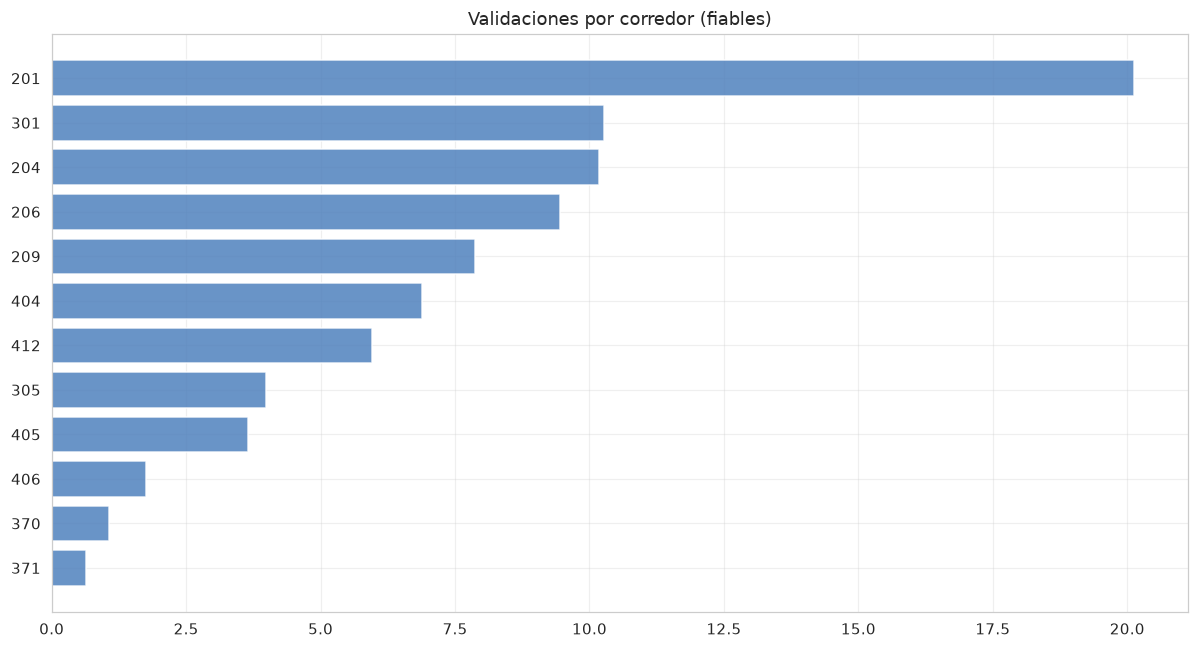

  [figura] docs/images/eda_corredores_ranking.png

Demanda por sentido (muestra rutas):
sentido_norm       E->O       N->S        O->E       S->N
ruta                                                     
201           9672123.0        0.0  10450590.0        0.0
204           5072405.0        0.0   5107601.0        0.0
206           4771714.0        0.0   4688949.0        0.0
209           4006627.0        0.0   3858728.0        0.0
301                 0.0  5244618.0         0.0  5019377.0
305                 0.0  2090007.0         0.0  1895203.0
370                 0.0   615055.0         0.0   444749.0
371                 0.0   291516.0         0.0   339100.0
404                 0.0  3381853.0         0.0  3498804.0
405                 0.0  1766852.0         0.0  1881295.0


In [9]:
perfil = df_f.groupby("hora")["validaciones"].mean() if len(df_f) else df.groupby("hora")["validaciones"].mean()
base = df_f if len(df_f) else df
pct = 100 * perfil / perfil.sum()
print(perfil.nlargest(5).round(0).to_string())
print(f"06-10h {pct[(pct.index>=6)&(pct.index<=10)].sum():.1f}% | 16-20h {pct[(pct.index>=16)&(pct.index<=20)].sum():.1f}%")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(perfil.index, perfil.values, color=COLOR, alpha=0.85, width=0.8)
ax.set_xticks(range(0,24)); ax.set_title("Perfil horario — Corredores (cobertura fiable)")
guardar_fig("eda_corredores_perfil_horario.png")

por_ruta = (base.groupby("ruta").agg(validaciones=("validaciones","sum"), dias=("fecha","nunique"))
            .sort_values("validaciones", ascending=False))
por_ruta["share_%"] = (100*por_ruta["validaciones"]/por_ruta["validaciones"].sum()).round(1)
print(por_ruta.round(0).to_string())
fig, ax = plt.subplots(figsize=(11, 6))
top = por_ruta.sort_values("validaciones")
ax.barh(top.index.astype(str), top["validaciones"]/1e6, color=COLOR, alpha=0.85)
ax.set_title("Validaciones por corredor (fiables)")
guardar_fig("eda_corredores_ranking.png")

por_sent = (base.groupby(["ruta","sentido_norm"], observed=True)["validaciones"].sum()
            .unstack(fill_value=0))
print("\nDemanda por sentido (muestra rutas):")
print(por_sent.head(10).to_string())


### 6.3 Fuentes externas de frecuencia (contexto)


In [10]:
fuentes = RAIZ / "data" / "fuentes"
prensa_p = fuentes / "frecuencias_corredores_prensa.csv"
apps_p = fuentes / "auditoria_apps_frecuencia.csv"
if prensa_p.exists():
    prensa = pd.read_csv(prensa_p)
    print("=== Prensa / tesis ===")
    cols = [c for c in ["corredor","servicio","min_pico","max_pico","anio","medio","confianza"] if c in prensa.columns]
    print(prensa[cols].to_string(index=False))
else:
    print("No está frecuencias_corredores_prensa.csv (corre download_transport_pages.py)")
if apps_p.exists():
    apps = pd.read_csv(apps_p)
    print("\n=== Auditoría apps ===")
    print(apps.head().to_string(index=False))


=== Prensa / tesis ===
corredor servicio  min_pico  max_pico  anio          medio confianza
    Azul     SE08         5         5  2025            RPP     media
    Azul     SE08         5         5  2025            RPP     media
    Azul     SE08         5         5  2025 Radio Nacional     media
    Azul     SE08         5         5  2025        Infobae     media
  Morado      404        15        15  2023      UPC tesis      baja


### 6.4 Correlación (ruta × día)


                 val_dia  hora_media_pond  n_paraderos    mes    dow  es_feriado_i
val_dia            1.000           -0.194        0.593  0.013 -0.229        -0.116
hora_media_pond   -0.194            1.000        0.007 -0.022  0.281         0.167
n_paraderos        0.593            0.007        1.000  0.015 -0.030        -0.017
mes                0.013           -0.022        0.015  1.000 -0.008         0.038
dow               -0.229            0.281       -0.030 -0.008  1.000         0.008
es_feriado_i      -0.116            0.167       -0.017  0.038  0.008         1.000


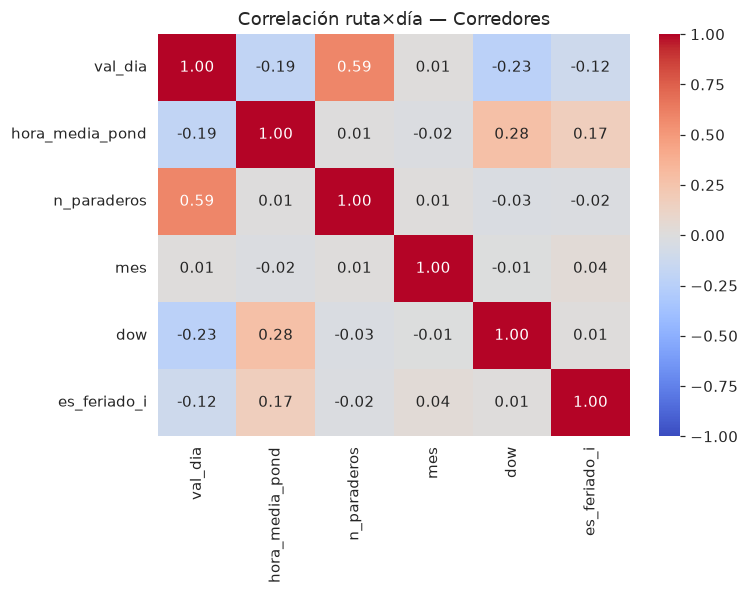

  [figura] docs/images/eda_corredores_correlacion.png


In [11]:
base = df_f if len(df_f) else df
tmp = (base.groupby(["ruta","fecha"], as_index=False)
       .apply(lambda g: pd.Series({
           "val_dia": g["validaciones"].sum(),
           "hora_media_pond": np.average(g["hora"].astype(float), weights=g["validaciones"]),
           "n_paraderos": g["cod_paradero"].nunique(),
       }), include_groups=False).reset_index(drop=True))
feat = base.groupby(["ruta","fecha","dia_semana","mes","es_feriado"], as_index=False).size().drop(columns="size")
feat = feat.merge(tmp, on=["ruta","fecha"])
feat["es_feriado_i"] = feat["es_feriado"].astype(int)
feat["dow"] = feat["dia_semana"].map({d:i for i,d in enumerate(DIAS)})
cols = ["val_dia","hora_media_pond","n_paraderos","mes","dow","es_feriado_i"]
corr = feat[cols].corr()
print(corr.round(3).to_string())
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación ruta×día — Corredores")
guardar_fig("eda_corredores_correlacion.png")


### Decisión missingness

- **NA (celda vacía Excel)**: `validaciones = 0` + `era_celda_vacia = True` (cero estructural de reporte).
- **Cero escrito**: se **conserva** (señal real de nula demanda).
- Plots de cola/IQR pueden filtrar `validaciones > 0` sin borrar el panel.
- Así el modelo de abordar/esperar/cambiar aprende también cuándo un paradero está vacío.


## Mapa de demanda (Folium)

Se elige `nivel` = `dia` | `dow` | `hora`.

Puntos desde `data/fuentes/geo/`; trazado LineString/shp cuando existe.
Los NA del Excel ya están como **0 + `era_celda_vacia`** en el panel (no sesgamos borrando ceros).


In [ ]:
GEO = RAIZ / "data" / "fuentes" / "geo"
FUENTES = RAIZ / "data" / "fuentes"
print("GeoJSON en", GEO)
print(list(GEO.glob("*.geojson")))

import json
import re
import unicodedata
from IPython.display import Image, display

try:
    import folium
    from branca.colormap import linear as _cm
except ImportError:
    folium = None
    _cm = None

LIMA = [-12.0464, -77.0428]


def _norm(s: str) -> str:
    t = unicodedata.normalize("NFKD", str(s).lower())
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.sub(r"[^a-z0-9]+", " ", t).strip()


def load_puntos_geojson(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=["unidad", "lat", "lon", "label"])
    fc = json.loads(path.read_text(encoding="utf-8"))
    rows = []
    for f in fc.get("features", []):
        props = f.get("properties", {})
        lon, lat = f["geometry"]["coordinates"][:2]
        unidad = props.get("unidad") or props.get("estacion") or props.get("cod_paradero")
        label = (
            props.get("estacion")
            or props.get("paradero")
            or props.get("cod_paradero")
            or str(unidad)
        )
        rows.append({"unidad": str(unidad), "lat": float(lat), "lon": float(lon), "label": str(label)})
    return pd.DataFrame(rows).drop_duplicates("unidad")


def find_mapa_atu_corredor(fuentes: Path, corredor: str, ruta: str):
    csv_p = Path(fuentes) / "mapas_corredores_atu.csv"
    if not csv_p.exists():
        return None
    t = pd.read_csv(csv_p)
    t = t[(t["corredor"].astype(str) == str(corredor)) & (t["ruta"].astype(str) == str(ruta))]
    t = t[t["ok"].astype(str).str.lower().isin(["true", "1"]) & t["archivo_local"].notna()]
    prefer = t[t["tipo"] == "mapa_ruta"]
    use = prefer if len(prefer) else t
    for _, r in use.iterrows():
        p = Path(fuentes) / str(r["archivo_local"])
        if p.exists():
            return p
    return None


def find_mapa_atu_metro(fuentes: Path, servicio_slug: str):
    csv_p = Path(fuentes) / "mapas_metropolitano_servicios_atu.csv"
    if not csv_p.exists():
        return None
    t = pd.read_csv(csv_p)
    t = t[t["servicio_slug"].astype(str) == str(servicio_slug)]
    t = t[t["ok"].astype(str).str.lower().isin(["true", "1"]) & t["archivo_local"].notna()]
    prefer = t[t["tipo"] == "mapa_ruta"]
    use = prefer if len(prefer) else t
    for _, r in use.iterrows():
        p = Path(fuentes) / str(r["archivo_local"])
        if p.exists():
            return p
    return None


def servicios_por_estacion(fuentes: Path) -> dict:
    p = Path(fuentes) / "estaciones_por_servicio_atu.csv"
    if not p.exists():
        return {}
    t = pd.read_csv(p)
    out = {}
    for est, g in t.groupby("estacion"):
        slugs = sorted(g["servicio_slug"].astype(str).unique())
        out[str(est)] = "Servicios: " + " | ".join(slugs)
    return out


def mapa_demanda(
    df, puntos, *, unidad_col, trazado=None, nivel="dow", fecha="2025-07-15",
    dia_sem="MAR", hora=8, color_linea="#1f4e79",
    trazado_filter=None, highlight_unidad=None, tooltip_extra=None, unidades_keep=None,
):
    if folium is None:
        print("Instala folium/branca para ver el mapa")
        return None
    if puntos is None or puntos.empty:
        print("Sin puntos geocodificados para este sistema")
        return None

    d = df.copy()
    d["fecha"] = pd.to_datetime(d["fecha"])
    if nivel == "dia":
        day = pd.Timestamp(fecha).date()
        sub = d[d["fecha"].dt.date == day]
        label = f"día {day}"
    elif nivel == "dow":
        sub = d[d["dia_semana"] == dia_sem]
        label = f"total de todos los {dia_sem} del periodo"
    else:
        sub = d[d["hora"].astype(int) == int(hora)]
        label = f"hora {int(hora):02d}:00 (todo el periodo)"

    print(f"Viendo {label}: {len(sub):,} filas, {sub['validaciones'].sum():,.0f} validaciones")
    if sub.empty:
        print("Sin datos para esa selección")
        return None

    agg = (
        sub.groupby(unidad_col, as_index=False)["validaciones"]
        .sum()
        .rename(columns={unidad_col: "unidad", "validaciones": "val"})
    )
    agg["unidad"] = agg["unidad"].astype(str)
    pts = puntos.copy()
    pts["unidad"] = pts["unidad"].astype(str)

    geo = agg.merge(pts, on="unidad", how="inner")
    if len(geo) < max(3, 0.3 * agg["unidad"].nunique()):
        agg2 = agg.copy()
        agg2["unidad_norm"] = agg2["unidad"].map(_norm)
        pts2 = pts.copy()
        pts2["unidad_norm"] = pts2["label"].map(_norm)
        pts2b = pts.copy()
        pts2b["unidad_norm"] = pts2b["unidad"].map(_norm)
        pts_n = pd.concat([pts2, pts2b]).drop_duplicates("unidad_norm")
        geo = agg2.merge(pts_n, on="unidad_norm", how="inner", suffixes=("", "_p"))
        if "label" not in geo.columns:
            geo["label"] = geo["unidad"]

    print(
        f"Unidades en mapa: {len(geo)} / {agg['unidad'].nunique()} con demanda en la selección "
        f"({100 * len(geo) / max(agg['unidad'].nunique(), 1):.1f}% geocodificadas)"
    )
    if unidades_keep is not None:
        keep = {str(x) for x in unidades_keep}
        geo = geo[
            geo["unidad"].astype(str).isin(keep)
            | geo.get("label", geo["unidad"]).astype(str).isin(keep)
        ].copy()
        print(f"  filtrado a unidades del trazado: {len(geo)}")
    if geo.empty:
        return None

    vmax = float(geo["val"].max()) if geo["val"].max() > 0 else 1.0
    cmap = _cm.YlOrRd_09.scale(0.0, float(np.log1p(vmax)))
    _fmt = lambda x: (f"{x/1e6:.1f}M" if x >= 1e6 else (f"{x/1e3:.0f}k" if x >= 1e3 else f"{x:.0f}"))
    _breaks = sorted({0.0, vmax} | {t for t in [1e3, 5e3, 1e4, 5e4, 1e5, 2.5e5, 5e5, 1e6] if 0 < t < vmax})

    def _pct(v):
        return float(np.log1p(v)) / float(np.log1p(vmax)) * 100

    _stops = ", ".join(f"{cmap(float(np.log1p(v)))} {_pct(v):.1f}%" for v in _breaks)
    _labels = "".join(
        f'<span style="position:absolute;left:{_pct(v):.1f}%;transform:translateX(-50%)">'
        f"{_fmt(v)}</span>" for v in [_breaks[0], _breaks[-1]]
    )
    leyenda = (
        '<div style="position:fixed;bottom:30px;right:15px;z-index:9999;background:#fff;'
        'padding:8px 14px;border-radius:6px;border:1px solid #ccc;'
        'box-shadow:0 1px 4px rgba(0,0,0,.2);font:12px sans-serif;line-height:1.2;">'
        '<div><b>Total de validaciones</b> <span style="color:#888">(escala log)</span></div>'
        '<div style="width:200px;height:12px;border-radius:3px;margin:6px 0 2px;'
        f'background:linear-gradient(to right, {_stops});"></div>'
        f'<div style="position:relative;width:200px;height:14px;">{_labels}</div>'
        f'<div style="margin-top:4px;color:#555;font-size:11px;">{label}</div>'
        "</div>"
    )

    m = folium.Map(location=LIMA, zoom_start=11, tiles="OpenStreetMap", height=500, width="100%")
    if trazado is not None and Path(trazado).exists():
        fc = json.loads(Path(trazado).read_text(encoding="utf-8"))
        if trazado_filter:
            key, val = next(iter(trazado_filter.items()))
            fc = {
                **fc,
                "features": [
                    f for f in fc.get("features", [])
                    if str(f.get("properties", {}).get(key, "")) == str(val)
                ],
            }
        if fc.get("features"):
            col0 = fc["features"][0].get("properties", {}).get("color_hex") or color_linea

            def _split_jumps(feat, max_km=3.0):
                geom = feat.get("geometry") or {}
                if geom.get("type") != "LineString":
                    return [feat]
                coords = geom.get("coordinates") or []
                if len(coords) < 2:
                    return [feat]
                segs, cur = [], [coords[0]]
                for i in range(1, len(coords)):
                    a = (coords[i - 1][1], coords[i - 1][0])
                    b = (coords[i][1], coords[i][0])
                    lon1, lat1 = np.radians(a[1]), np.radians(a[0])
                    lon2, lat2 = np.radians(b[1]), np.radians(b[0])
                    dlat, dlon = lat2 - lat1, lon2 - lon1
                    x = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
                    km = float(2 * 6371 * np.arcsin(np.sqrt(x)))
                    if km > max_km:
                        if len(cur) >= 2:
                            segs.append(cur)
                        cur = [coords[i]]
                    else:
                        cur.append(coords[i])
                if len(cur) >= 2:
                    segs.append(cur)
                out = []
                for s in segs:
                    out.append({
                        "type": "Feature",
                        "properties": dict(feat.get("properties") or {}),
                        "geometry": {"type": "LineString", "coordinates": s},
                    })
                return out or [feat]

            feats2 = []
            for f in fc["features"]:
                feats2.extend(_split_jumps(f))
            fc = {**fc, "features": feats2}
            folium.GeoJson(
                fc,
                name="Trazado",
                style_function=lambda _, c=col0: {"color": c, "weight": 3, "opacity": 0.75},
            ).add_to(m)

    r = np.sqrt(geo["val"] / vmax) * 14 + 3
    highlight_norm = _norm(highlight_unidad) if highlight_unidad else None
    for i, row in geo.iterrows():
        c = cmap(float(np.log1p(row["val"])))
        tip = f"{row.get('label', row['unidad'])}<br>{row['val']:,.0f} validaciones"
        if tooltip_extra and row["unidad"] in tooltip_extra:
            tip += f"<br>{tooltip_extra[row['unidad']]}"
        weight = 1
        if highlight_norm and _norm(str(row.get("label", row["unidad"]))) == highlight_norm:
            weight = 4
            c = "#0d47a1"
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=float(r.loc[i]),
            color=c, fillColor=c, fill=True,
            fillOpacity=0.85, weight=weight, opacity=0.9,
            tooltip=tip,
        ).add_to(m)

    m.get_root().html.add_child(folium.Element(leyenda))
    folium.LayerControl(collapsed=False).add_to(m)
    return m


In [ ]:
# Burbujas = validaciones por paradero | Línea = trazado de UNA ruta ATU
# Alternativas corredor_mapa:
#   "Rojo" | "Azul" | "Morado"
#
# Alternativas ruta_mapa por corredor:
#   Rojo:   201, 204, 206, 209, 257, 409
#   Azul:   301, 302, 303, 305, 306, 336, 370, 371
#   Morado: 401, 404, 405, 406, 412, 601
#
# paradero_mapa: None  o  un cod_paradero / nombre para resaltar
# nivel: "dia" | "dow" | "hora"
# dia_sem: "LUN"|"MAR"|"MIE"|"JUE"|"VIE"|"SAB"|"DOM"

corredor_mapa = "Rojo"
ruta_mapa = "204"
paradero_mapa = None
nivel = "dow"
fecha = "2025-07-15"
dia_sem = "MAR"
hora = 8

COLOR = {"Rojo": "#c0392b", "Azul": "#2471a3", "Morado": "#7d3c98"}

img = find_mapa_atu_corredor(FUENTES, corredor_mapa, ruta_mapa)
if img is not None:
    print("Mapa oficial ATU:", img)
    display(Image(filename=str(img), width=700))
else:
    print("Sin imagen ATU para", corredor_mapa, ruta_mapa, "(corre download_atu_mapas.py)")

fc = json.loads((GEO / "puntos_corredores.geojson").read_text(encoding="utf-8"))
rows = []
for f in fc["features"]:
    if str(f["properties"].get("ruta")) != str(ruta_mapa):
        continue
    lon, lat = f["geometry"]["coordinates"][:2]
    rows.append({
        "unidad": str(f["properties"].get("cod_paradero")),
        "lat": lat, "lon": lon,
        "label": str(f["properties"].get("paradero") or f["properties"].get("cod_paradero")),
    })
puntos_ruta = pd.DataFrame(rows).drop_duplicates("unidad")
print("paraderos ruta", ruta_mapa, ":", len(puntos_ruta))

_df_map = df[df["ruta"].astype(str) == str(ruta_mapa)].copy() if "ruta" in df.columns else df.copy()

m = mapa_demanda(
    _df_map, puntos_ruta,
    unidad_col="cod_paradero" if "cod_paradero" in _df_map.columns else "paradero",
    trazado=GEO / "trazados_corredores.geojson",
    trazado_filter={"ruta": str(ruta_mapa)},
    nivel=nivel, fecha=fecha, dia_sem=dia_sem, hora=hora,
    color_linea=COLOR.get(corredor_mapa, "#4f81bd"),
    highlight_unidad=paradero_mapa,
    unidades_keep=puntos_ruta["unidad"].tolist() if len(puntos_ruta) else None
)
m  # se renderiza inline (como week07)


### 6.5 Conclusiones

1. Cobertura heterogénea: solo un subconjunto de rutas es usable para promedios anuales.
2. `TIPO DE DÍA` del archivo es redundante con el calendario; feriados van por `es_feriado`.
3. Algunos sentidos corruptos (`sentido_norm` nulo), vamos a excluir al analizar dirección.
4. Outliers IQR se conservan.
5. Salida: `corredores_hora.parquet`.


In [14]:
cols_out = ["fecha","anio","mes","dia_semana","tipo_dia","semana_iso","feriado","es_feriado",
            "ruta","cod_paradero","paradero","sentido","sentido_crudo","sentido_norm","eje",
            "hora","franja","validaciones","log_val","es_outlier_iqr", "era_celda_vacia",
            "tipo_dia_archivo","tipo_dia_coincide"]
out = df[cols_out].sort_values(["fecha","ruta","sentido_norm","cod_paradero","hora"])
out.to_parquet(CLEAN / "corredores_hora.parquet", index=False, compression="snappy")
print(f"corredores_hora: {len(out):,}")
cob.rename(columns={"ruta":"unidad"}).assign(sistema="corredor").to_csv(
    CLEAN / "calidad_cobertura_corredor.csv", index=False)


corredores_hora: 8,254,152
